## K_Means_Clustering
1. Use Iris Flowe dataset from sklearn library and try to form clusters of flowers using petal width and length  features. 
Drop other two features for simplicity.

## Libraries

In [36]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Load the Data

In [2]:
# Load the Iris Dataset
df = sns. load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


We try to form clusters of flowers using Petal width and length features. So we drop other two features like sepal length and sepal width. 
So, First we Preprocess the data and drop these two features 

In [ ]:
df.drop('sepal_length', axis=1, inplace= True)
df.drop('sepal_width', axis=1, inplace=True)

In [10]:
df

,petal_length,petal_width,species
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa
...,...,...,...
145,5.2,2.3,virginica
146,5.0,1.9,virginica
147,5.2,2.0,virginica
148,5.4,2.3,virginica


## Scale the Data

In [37]:
scaler = StandardScaler()
df['petal_length'] = scaler.fit_transform(df[['petal_length']])
df['petal_width'] = scaler.fit_transform(df[['petal_width']])
df

,petal_length,petal_width,species,cluster
0,-1.340227,-1.315444,setosa,0
1,-1.340227,-1.315444,setosa,0
2,-1.397064,-1.315444,setosa,0
3,-1.283389,-1.315444,setosa,0
4,-1.340227,-1.315444,setosa,0
...,...,...,...,...
145,0.819596,1.448832,virginica,1
146,0.705921,0.922303,virginica,1
147,0.819596,1.053935,virginica,1
148,0.933271,1.448832,virginica,1


## Scatter Plot
First we make scatter plot to show the clusters of Petal length and width.

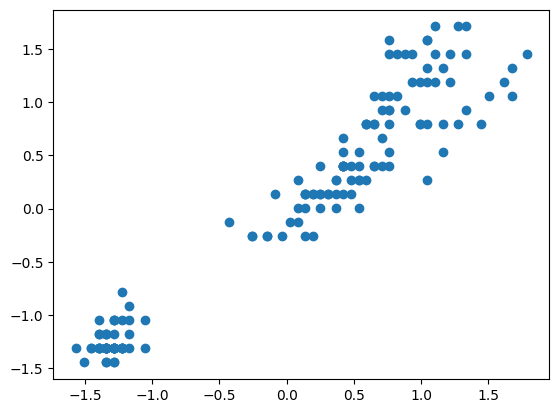

In [38]:
plt.scatter(df['petal_length'], df['petal_width'])

## We apply algorithm

In [39]:
km = KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [40]:
y_predicted = km.fit_predict(df[['petal_length', 'petal_width']])
y_predicted

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [41]:
df['cluster'] = y_predicted 
df.head()

,petal_length,petal_width,species,cluster
0,-1.340227,-1.315444,setosa,1
1,-1.340227,-1.315444,setosa,1
2,-1.397064,-1.315444,setosa,1
3,-1.283389,-1.315444,setosa,1
4,-1.340227,-1.315444,setosa,1


In [42]:
km.cluster_centers_

array([[ 1.02799959,  1.12797813],
       [-1.30498732, -1.25489349],
       [ 0.3058728 ,  0.16541778]])

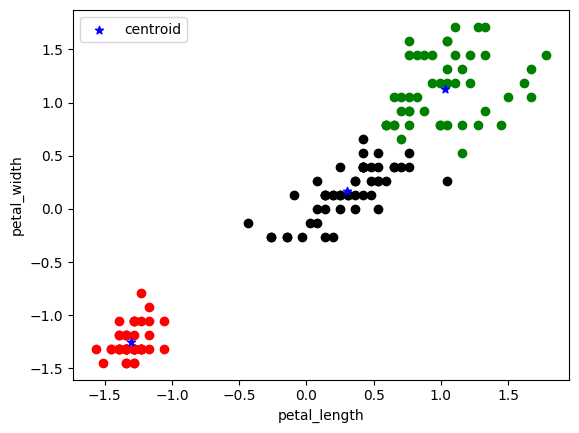

In [43]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1['petal_length'], df1['petal_width'], color = 'green')
plt.scatter(df2['petal_length'], df2['petal_width'], color = 'red')
plt.scatter(df3['petal_length'], df3['petal_width'], color = 'black')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color = 'blue', marker = '*', label = 'centroid')
plt.xlabel('petal_length')
plt.ylabel('petal_width')
plt.legend()